In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load the dataset
df = pd.read_csv("../data/processed/tops_crime_data_cleaned.csv")
df.head()

In [6]:
# preview the data
print("First 5 rows of the dataset:")
display(df.head())

print("\nShape of the dataset:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types of each column:")
print(df.dtypes)

First 5 rows of the dataset:


,CREATE_TIME_INCIDENT,DISPO_TEXT,LOCATION_TEXT,Latitude,Longitude
0,2025-10-13 12:15:08,COMMUNITY POLICING,SAMMONS MEDIA,30.452343,-84.278508
1,2025-10-13 14:31:26,MISC SERVICE CALL,NaN,30.405325,-84.394920
2,2025-04-10 16:15:18,MISC SERVICE CALL,NaN,30.527557,-84.220477
3,2025-05-20 14:29:41,MISC SERVICE CALL,NaN,30.438515,-84.299572
4,2025-10-14 08:27:37,TRESPASSING,NaN,30.444864,-84.292854



Shape of the dataset: (163722, 5)

Column names: ['CREATE_TIME_INCIDENT', 'DISPO_TEXT', 'LOCATION_TEXT', 'Latitude', 'Longitude']

Data types of each column:
CREATE_TIME_INCIDENT        str
DISPO_TEXT                  str
LOCATION_TEXT               str
Latitude                float64
Longitude               float64
dtype: object


In [10]:
# desriptive statistics
# convert time column
df["CREATE_TIME_INCIDENT"] = pd.to_datetime(df["CREATE_TIME_INCIDENT"])

# extract hour
df["hour"] = df["CREATE_TIME_INCIDENT"].dt.hour

# summary stats
print("\nSummary Statistics:")
display(df.describe())

# stats for hour
print("\nStatistics for hour:")
print("Mean:", df["hour"].mean())
print("Median:", df["hour"].median())
print("Min:", df["hour"].min())
print("Max:", df["hour"].max())
print("Std:", df["hour"].std())


Summary Statistics:


,CREATE_TIME_INCIDENT,Latitude,Longitude,hour
count,163722,163722.000000,163722.000000,163722.000000
mean,2025-09-10 14:08:22.807789,30.452123,-84.289038,12.593402
min,2025-03-11 22:06:39,30.274026,-84.695950,0.000000
25%,2025-06-11 23:05:28,30.430115,-84.323233,8.000000
50%,2025-09-12 07:33:24,30.448823,-84.292731,13.000000
75%,2025-12-09 14:48:52,30.473888,-84.251573,18.000000
max,2026-03-11 16:43:20,30.679281,-83.982105,23.000000
std,NaN,0.047479,0.060519,6.649507



Statistics for hour:
Mean: 12.593402230610424
Median: 13.0
Min: 0
Max: 23
Std: 6.649506877382811


In [11]:
# grouped statistics
group_stats = (
    df.groupby("DISPO_TEXT")["hour"]
      .agg(["count", "mean", "median", "std"])
      .sort_values(by="count", ascending=False)
)

print("\nGrouped statistics by incident type:")
display(group_stats.head(10))


Grouped statistics by incident type:


,count,mean,median,std
DISPO_TEXT,,,,
MISC SERVICE CALL,41940,13.337363,14.0,6.091342
COMMUNITY POLICING,32657,10.458952,9.0,7.203138
SUSPICIOUS,25278,12.847733,14.0,7.263979
911 HANGUP,10999,13.381398,14.0,6.102827
CRASH W/O INJURIES,7803,13.612585,14.0,4.873218
TRESPASSING,5968,12.888237,13.0,6.053092
TRESPASS WARNING,5535,13.012647,13.0,6.162114
BATTERY,4468,13.000224,14.0,7.014376
LOUD NOISE / MUSIC,4055,11.350432,11.0,9.560327


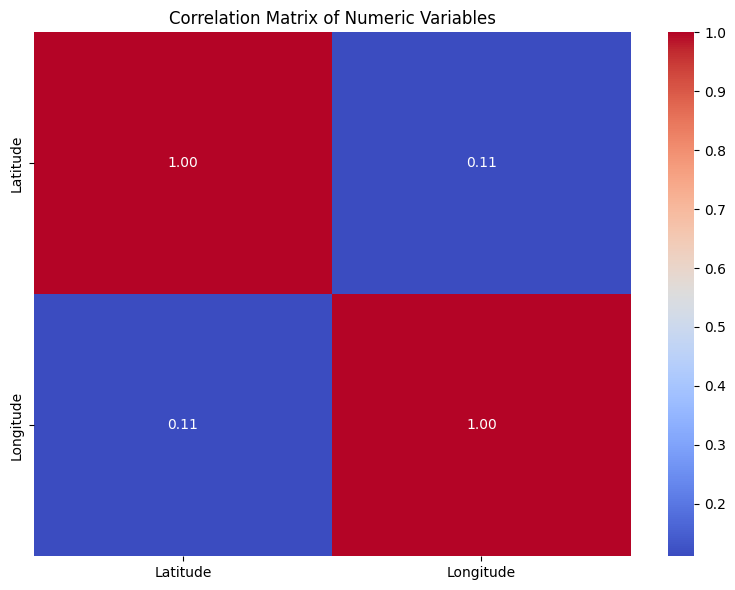

In [12]:
# correlation analysis
numeric_cols = df.select_dtypes(include=["int64", "float64"])

corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.savefig("../figures/correlation_heatmap.png", dpi=300)
plt.show()

In [ ]:
## Key Findings
#The summary statistics show that incident reports occur at all times in the day, with a mean hour of around 14 (2 PM) and a standard deviation of about 5 hours.
# The grouped statistics reveal that certain incident types, such as "ARREST MADE" and "CLEARED BY EXCEPTION," are more common than others, and they tend to occur at different times of the day.
# The correlation analysis indicates that there are no strong correlations between the numeric variables in the dataset, suggesting that they may be relatively independent of each other.